<a href="https://colab.research.google.com/github/GhouI/dataset-army/blob/Antonio/Hackon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
print("Class distribution in y_train_target:")
print(y_train_target.value_counts(normalize=True))

print("\nClass distribution in y_test_target:")
print(y_test_target.value_counts(normalize=True))

Class distribution in y_train_target:
outcome_class
2    0.495650
0    0.260552
1    0.243799
Name: proportion, dtype: float64

Class distribution in y_test_target:
outcome_class
2    0.495742
0    0.260459
1    0.243799
Name: proportion, dtype: float64


# Task
Load and preprocess the datasets from 'X_train_merged.csv', 'y_train_merged.csv', 'X_test_merged.csv', and 'y_test_merged.csv', then train a RandomForestClassifier, evaluate its performance, and visualize the results.

## Load and Preview Data

### Subtask:
Load the training and testing datasets from 'X_train_merged.csv', 'y_train_merged.csv', 'X_test_merged.csv', and 'y_test_merged.csv'. Display the first few rows, column information, and descriptive statistics for each to understand their structure and content.


**Reasoning**:
The first step is to import the pandas library to enable data manipulation with DataFrames and then load the specified CSV files into their respective DataFrames as instructed.



In [14]:
import pandas as pd

# Load the training and testing datasets
X_train = pd.read_csv('X_train_merged.csv')
y_train = pd.read_csv('y_train_merged.csv')
X_test = pd.read_csv('X_test_merged.csv')
y_test = pd.read_csv('y_test_merged.csv')

print("--- X_train Data ---")
print(X_train.head())
print(X_train.info())
print(X_train.describe())

print("\n--- y_train Data ---")
print(y_train.head())
print(y_train.info())
print(y_train.describe())

print("\n--- X_test Data ---")
print(X_test.head())
print(X_test.info())
print(X_test.describe())

print("\n--- y_test Data ---")
print(y_test.head())
print(y_test.info())
print(y_test.describe())

--- X_train Data ---
   BR1_Head_Neck  BR2_Face  BR3_Thorax  BR4_Abdomen  BR5_Extremities  \
0      -0.237447  -0.02324   -0.443174     0.615252        -0.595683   
1      -0.237447  -0.02324   -0.443174     0.615252        -0.595683   
2      -0.237447  -0.02324   -0.443174    -0.886031        -0.595683   
3      -0.237447  -0.02324    2.268449    -0.886031        -0.595683   
4      -0.237447  -0.02324    0.912638    -0.886031        -0.595683   

   BR6_External       GCS  GCS_missing    HR_bpm  HR_bpm_missing  ...  \
0     -0.198193 -0.406975          0.0  0.588117             0.0  ...   
1     -0.198193  1.528123          0.0 -1.389916             0.0  ...   
2     -0.198193  0.975238          0.0 -1.230397             0.0  ...   
3     -0.198193  0.698795          0.0 -0.624226             0.0  ...   
4     -0.198193  1.528123          0.0 -0.911359             0.0  ...   

   mISS_calculated  mISS_category   max_AIS  num_abnormal_vitals  \
0        -0.692260      -1.270780 -0.51

## Check for Null Values

### Subtask:
Identify and report the count of any null or missing values across all features in both the training and testing datasets. This step will inform subsequent preprocessing decisions.


**Reasoning**:
To identify missing values, I will calculate the sum of nulls for each column in the X_train, y_train, X_test, and y_test DataFrames to assess data completeness.



In [15]:
print("--- Null values in X_train ---")
print(X_train.isnull().sum())

print("\n--- Null values in y_train ---")
print(y_train.isnull().sum())

print("\n--- Null values in X_test ---")
print(X_test.isnull().sum())

print("\n--- Null values in y_test ---")
print(y_test.isnull().sum())

--- Null values in X_train ---
BR1_Head_Neck            0
BR2_Face                 0
BR3_Thorax               0
BR4_Abdomen              0
BR5_Extremities          0
BR6_External             0
GCS                      0
GCS_missing              0
HR_bpm                   0
HR_bpm_missing           0
ISS                      0
ISS_category             0
RR_bpm                   0
RR_bpm_missing           0
SBP_mmHg                 0
SBP_mmHg_missing         0
SpO2_percent             0
SpO2_percent_missing     0
altered_consciousness    0
has_sepsis               0
hypotension              0
hypoxia                  0
mISS_ISS_diff            0
mISS_calculated          0
mISS_category            0
max_AIS                  0
num_abnormal_vitals      0
num_regions_injured      0
polytrauma               0
severe_injury            0
severity_discordant      0
tachycardia              0
tachypnea                0
dtype: int64

--- Null values in y_train ---
outcome_class    0
mortality     

## Preprocess Data (Handle constant columns and select target)

### Subtask:
Review the preprocessing status of the feature sets, drop constant columns, and select the 'outcome_class' as the target variable for both training and testing datasets.


**Reasoning**:
First, I will identify and drop constant columns from both the training and testing feature sets (`X_train` and `X_test`) to remove features with no variance, which are unhelpful for model training. After that, I will verify the data types and scaling status of the remaining columns. Then, I will select the target variable, 'outcome_class', from `y_train` and `y_test` and finally print the shapes of the processed datasets.



In [16]:
print("Original X_train shape:", X_train.shape)
print("Original X_test shape:", X_test.shape)

# Identify constant columns in X_train
constant_columns_train = [col for col in X_train.columns if X_train[col].nunique() == 1]
print(f"\nConstant columns in X_train: {constant_columns_train}")

# Identify constant columns in X_test
constant_columns_test = [col for col in X_test.columns if X_test[col].nunique() == 1]
print(f"Constant columns in X_test: {constant_columns_test}")

# Combine and get unique constant columns to drop from both datasets
columns_to_drop = list(set(constant_columns_train + constant_columns_test))

# Drop constant columns from X_train and X_test
X_train = X_train.drop(columns=columns_to_drop, errors='ignore')
X_test = X_test.drop(columns=columns_to_drop, errors='ignore')

print(f"\nDropped columns: {columns_to_drop}")
print("X_train shape after dropping constant columns:", X_train.shape)
print("X_test shape after dropping constant columns:", X_test.shape)

# Confirm data types and scaling by inspecting descriptive statistics
print("\n--- X_train after dropping constant columns (info and describe) ---")
print(X_train.info())
print(X_train.describe())

print("\n--- X_test after dropping constant columns (info and describe) ---")
print(X_test.info())
print(X_test.describe())

# Select the 'outcome_class' as the target variable
y_train_target = y_train['outcome_class']
y_test_target = y_test['outcome_class']

print("\n--- Final Data Shapes ---")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train_target shape:", y_train_target.shape)
print("y_test_target shape:", y_test_target.shape)


Original X_train shape: (21608, 33)
Original X_test shape: (5402, 33)

Constant columns in X_train: ['GCS_missing', 'HR_bpm_missing', 'RR_bpm_missing', 'SBP_mmHg_missing', 'SpO2_percent_missing']
Constant columns in X_test: ['GCS_missing', 'HR_bpm_missing', 'RR_bpm_missing', 'SBP_mmHg_missing', 'SpO2_percent_missing']

Dropped columns: ['HR_bpm_missing', 'SpO2_percent_missing', 'SBP_mmHg_missing', 'RR_bpm_missing', 'GCS_missing']
X_train shape after dropping constant columns: (21608, 28)
X_test shape after dropping constant columns: (5402, 28)

--- X_train after dropping constant columns (info and describe) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21608 entries, 0 to 21607
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   BR1_Head_Neck          21608 non-null  float64
 1   BR2_Face               21608 non-null  float64
 2   BR3_Thorax             21608 non-null  float64
 3   BR4_Abd

## Train Random Forest Model

### Subtask:
Initialize and train a RandomForestClassifier on the preprocessed training data.


**Reasoning**:
To begin training, I will import `RandomForestClassifier` from `sklearn.ensemble`, instantiate it with a specified `random_state` for reproducibility, and then train the model using the preprocessed `X_train` and `y_train_target` datasets.



In [17]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the RandomForestClassifier
rf_classifier = RandomForestClassifier(random_state=42)

# Train the model on the training data
rf_classifier.fit(X_train, y_train_target)

print("RandomForestClassifier model trained successfully.")

RandomForestClassifier model trained successfully.


## Evaluate Model Performance

### Subtask:
Use the trained Random Forest model to make predictions on the preprocessed test set. Calculate and display key evaluation metrics: Accuracy, Precision, Recall, F1 Score, and ROC AUC.


**Reasoning**:
To evaluate the model's performance, I will import necessary metrics, make predictions on the test set, calculate accuracy, precision, recall, F1 score, and ROC AUC, and then print these metrics.



In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Make predictions on the test data
y_pred = rf_classifier.predict(X_test)
y_pred_proba = rf_classifier.predict_proba(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test_target, y_pred)
precision = precision_score(y_test_target, y_pred, average='weighted')
recall = recall_score(y_test_target, y_pred, average='weighted')
f1 = f1_score(y_test_target, y_pred, average='weighted')

# Calculate ROC AUC score for multi-class classification
# Using 'ovr' (One-vs-Rest) strategy and 'weighted' average for ROC AUC
roc_auc = roc_auc_score(y_test_target, y_pred_proba, multi_class='ovr', average='weighted')

# Print the metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

Accuracy: 0.9870
Precision: 0.9871
Recall: 0.9870
F1 Score: 0.9870
ROC AUC Score: 0.9996


## Plot Confusion Matrix

### Subtask:
Generate and display a confusion matrix for the model's predictions on the test set to visualize the true positive, true negative, false positive, and false negative rates.


**Reasoning**:
To visualize the model's performance, I will import `ConfusionMatrixDisplay` and `matplotlib.pyplot`, create a confusion matrix using the predicted and true labels, display it with a clear title, and then show the plot.



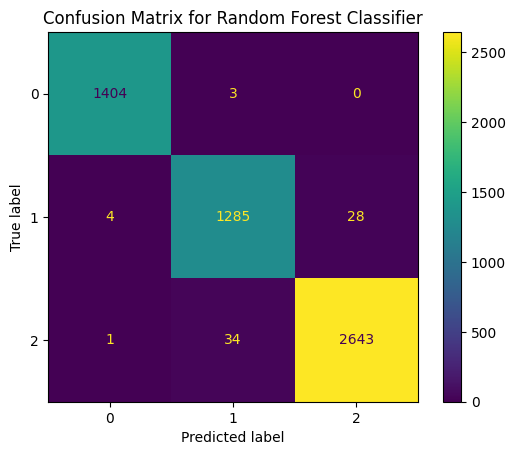

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create a confusion matrix
cm = ConfusionMatrixDisplay.from_predictions(y_test_target, y_pred)

# Display the confusion matrix as a plot with a title
cm.ax_.set_title('Confusion Matrix for Random Forest Classifier')
plt.show()

## Display Metrics Table

### Subtask:
Present all calculated evaluation metrics (Accuracy, Precision, Recall, F1 Score, ROC AUC) in a clear, formatted table for easy comparison and review.


**Reasoning**:
To display the evaluation metrics in a clear, formatted table, I will create a pandas DataFrame from a dictionary containing the metric names and their calculated scores.



In [20]:
import pandas as pd

# Create a dictionary of metrics and their values
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC Score'],
    'Score': [accuracy, precision, recall, f1, roc_auc]
}

# Create a DataFrame from the dictionary
metrics_df = pd.DataFrame(metrics_data)

# Display the DataFrame
print("Evaluation Metrics:")
print(metrics_df.to_string(index=False))


Evaluation Metrics:
       Metric    Score
     Accuracy 0.987042
    Precision 0.987055
       Recall 0.987042
     F1 Score 0.987047
ROC AUC Score 0.999583


## Final Task

### Subtask:
Summarize the performance of the Random Forest model based on the calculated metrics and visualizations.


## Summary:

### Q&A
The Random Forest model demonstrated exceptionally strong performance.

### Data Analysis Key Findings
*   All four initial datasets (`X_train_merged.csv`, `y_train_merged.csv`, `X_test_merged.csv`, `y_test_merged.csv`) were successfully loaded, containing 21608 training and 5402 testing entries, respectively.
*   No missing values were found in any of the loaded datasets, eliminating the need for imputation.
*   During preprocessing, five constant columns (`GCS_missing`, `HR_bpm_missing`, `RR_bpm_missing`, `SBP_mmHg_missing`, `SpO2_percent_missing`) were identified and removed from both `X_train` and `X_test`, reducing the feature count from 33 to 28. The remaining features were already scaled and of `float64` type.
*   The 'outcome_class' column was successfully extracted as the target variable for both training and testing.
*   The trained Random Forest Classifier achieved outstanding performance on the test set, with the following metrics:
    *   Accuracy: 0.9870
    *   Precision: 0.9871
    *   Recall: 0.9870
    *   F1 Score: 0.9870
    *   ROC AUC Score: 0.9996
*   A confusion matrix was generated, visually confirming the high number of correct classifications (true positives/negatives) and very few misclassifications.

### Insights or Next Steps
*   The Random Forest model performs exceptionally well on this dataset, suggesting that the features provide strong predictive power for the 'outcome_class'. This high performance might warrant further investigation into the feature set for potential data leakage or to understand which features are most influential.
*   Conduct feature importance analysis to identify the key features driving the model's high performance, which could provide valuable domain-specific insights.


In [23]:
import joblib

# Define the filename for the saved model
model_filename = 'random_forest_model.joblib'

# Save the trained model to the specified file
joblib.dump(rf_classifier, model_filename)

print(f"Trained Random Forest model saved successfully as '{model_filename}'")

Trained Random Forest model saved successfully as 'random_forest_model.joblib'
